# 019c template

In [1]:
import h5py
import matplotlib
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.patches as patches
import matplotlib as mpl
#import importlib
from scipy import ndimage
import matplotlib.colors as colors
#from h5glance import H5Glance as h5p
import sys
sys.path.append('./tools/')
import Toolbox as tl
import math_nem as ne
import SDXM
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit
import pwlf
#from astropy.stats import histogram as astrohist
from importlib import reload as f5
plt.style.use('petroff10')

In [2]:
sample_name = '019f_10nm_YSZ'
proposal = '20240449'
visit = '2024090408'
path_root = f'/data/visitors/nanomax/{proposal}/{visit}/raw/{sample_name}'
save_root = '/mxn/home/leooli/jupyter_notebooks/analysis/achiles_data/'

### Selecting scans for analysis

In [3]:
#####################
start_scan = 250
end_scan = 261
scans = np.arange(start_scan, end_scan + 1)
#
scans = [243] + list(scans)  + list(np.arange(266, 275 +1)) + list(np.arange(281, 292 +1)) + list(np.arange(295, 371 +1))
scans = [int(x) for x in scans]
scan_paths = [f"{path_root}/0000{i}.h5" if i < 100 else f"{path_root}/000{i}.h5" for i in scans]
#####################
voltage = []
scan_true = []
meas_current = []

for i, j in enumerate(tqdm(scan_paths)):
    try:
        command = tl.get_command(j)
        #
        if command.split()[0] != "ascan":
            scan_true.append(j)  # this will append only real scans, not voltage ramping up
            
            #
            with h5py.File(j, 'r') as scan_voltage:
                voltage.append(np.array(scan_voltage['/entry/snapshots/pre_scan/keysight_bias'][0]))
                current = np.min(scan_voltage['entry/measurement/keysight'][:])
                meas_current.append(current)
    
    except Exception as e:  # Catch all exceptions and print/log them
        print(f"An error occurred while processing {j}: {e}")
####################
voltage_fixed = np.copy(voltage)
scan_fixed = np.copy(scan_true)
current_fixed = np.copy(meas_current)
########################################### deleting scans with memory issues
scan_fixed = np.delete(scan_fixed, 11)
voltage_fixed = np.delete(voltage_fixed, 11)
current_fixed = np.delete(current_fixed, 11)
#
scan_fixed = np.delete(scan_fixed, 10)
voltage_fixed = np.delete(voltage_fixed, 10)
current_fixed = np.delete(current_fixed, 10)
#
####################
voltage_fixed = np.array(voltage_fixed[0: -1])
scan_fixed = np.array(scan_fixed[0: -1])
current_fixed = np.array(current_fixed[0: -1])
###################
###################
scan_fixed_ref = scan_fixed[0]
################### selecting scans with same exposure time
voltage_fixed = np.array(voltage_fixed[0: 16])
scan_fixed = np.array(scan_fixed[0: 16])
current_fixed = np.array(current_fixed[0: 16])

 34%|███▍      | 38/112 [00:00<00:00, 172.00it/s]

An error occurred while processing /data/visitors/nanomax/20240449/2024090408/raw/019f_10nm_YSZ/000274.h5: Unable to synchronously open file (bad object header version number)
An error occurred while processing /data/visitors/nanomax/20240449/2024090408/raw/019f_10nm_YSZ/000275.h5: "Unable to synchronously open object (object 'keysight_bias' doesn't exist)"


100%|██████████| 112/112 [00:00<00:00, 114.99it/s]


### IV curve per scan

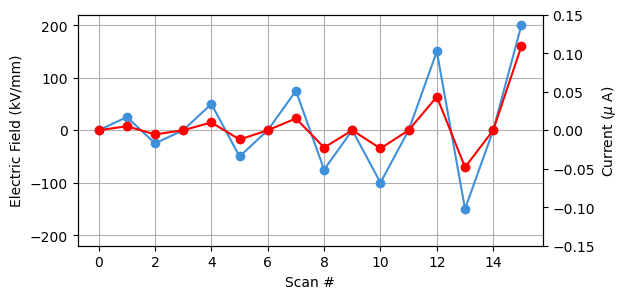

In [4]:
fig, ax = plt.subplots(figsize = (6,3))
m_values= []
j_values = []
i_values = []
c_values = []
nums = 0
for m, (i, j, c) in enumerate(zip(scan_fixed, voltage_fixed, current_fixed)):
       #print(m, j)
    m_values.append(m)
    j_values.append(j)
    i_values.append(nums)
    c_values.append(c)
    nums = nums + 1
ax.plot(i_values, [i*1e3/20 for i in j_values], marker='o', linestyle='-')
ax.set_ylabel('Electric Field (kV/mm)')
ax.set_xlabel('Scan #')
ax1 = ax.twinx()
ax1.plot(i_values, [i/1e-6 for i in c_values], color = 'r', marker='o', linestyle='-')
ax1.set_ylabel(r'Current $(\mu$ A)')
ax1.set_ylim(-0.15, 0.15)
ax.set_ylim(-220, 220)
ax.grid()

In [5]:
for m , (i, j) in enumerate(zip(scan_fixed, voltage_fixed)):
    with h5py.File(i, 'r') as h5:
        #if m == 1:
            data = np.mean(h5['entry/measurement/keysight'][:])
            
            sx = h5['entry/snapshots/pre_scan/sx'][:]
            sy = h5['entry/snapshots/pre_scan/sy'][:]
            sz = h5['entry/snapshots/pre_scan/sz'][:]
            
            description = h5['entry/description'][:]
            #print(data)
            print(m, i.split('/')[-1], j, np.shape(data), description, np.round(sx,3), np.round(sy,3), np.round(sz,3))
#####################################################################
voltage_fixed_kvmm = [i*1e3/20 for i in voltage_fixed]
voltage_fixed_kvmm = np.array(voltage_fixed_kvmm)

0 000243.h5 0.0 () [b'npointflyscan sx -5 15 322 sy -5 5 33 0.05'] [-5.061] [45.] [-0.001]
1 000250.h5 0.5 () [b'npointflyscan sx -5 15 160 sy -5 5 15 0.05'] [-5.124] [-1.667] [0.]
2 000252.h5 -0.5 () [b'npointflyscan sx -5 15 160 sy -5 5 15 0.05'] [-5.124] [4.999] [-0.001]
3 000254.h5 0.0 () [b'npointflyscan sx -5 15 160 sy -5 5 15 0.05'] [-5.125] [5.] [0.001]
4 000256.h5 1.0 () [b'npointflyscan sx -5 15 160 sy -5 5 15 0.05'] [-5.124] [5.] [0.]
5 000258.h5 -1.0 () [b'npointflyscan sx -5 15 160 sy -5 5 15 0.05'] [-5.124] [5.002] [-0.001]
6 000260.h5 0.0 () [b'npointflyscan sx -5 15 160 sy -5 5 15 0.05'] [-5.124] [5.] [0.002]
7 000266.h5 1.5 () [b'npointflyscan sx -5 15 160 sy -5 5 15 0.05'] [-5.124] [4.332] [-0.002]
8 000268.h5 -1.5 () [b'npointflyscan sx -5 15 160 sy -5 5 15 0.05'] [-5.122] [4.998] [0.]
9 000270.h5 0.0 () [b'npointflyscan sx -5 15 160 sy -5 5 15 0.05'] [-5.123] [5.] [0.001]
10 000281.h5 -2.0 () [b'npointflyscan sx -5 15 160 sy -5 5 15 0.05'] [-5.123] [0.5] [0.001]
11 

### Selecting ROIS

/mxn/home/leooli/jupyter_notebooks/analysis/achiles_data/scripts_good/new/SDXM.py:182: RuntimeWarning: divide by zero encountered in log10
  ax[0].imshow(np.log10(frame_sum), vmax = np.percentile(np.log10(frame_sum), percentile), cmap = 'terrain') # vmax = np.percentile(masked_data, 99.999))


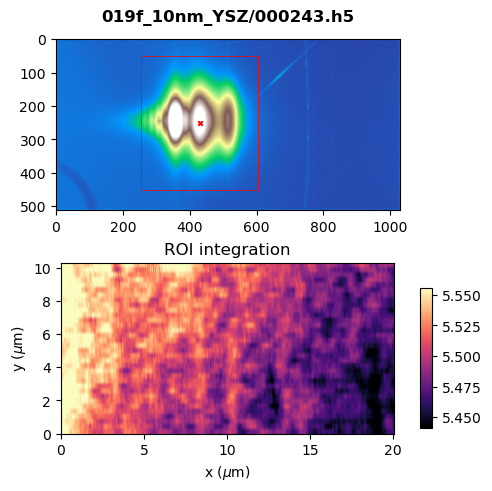

In [6]:
f5(SDXM)
#ROI = SDXM.ROI(270, 750, 450, 30) #wire
ROI = SDXM.ROI(250, 430, 400, 350) #all
XRD_4dmaps, ext , _ = SDXM.plotscan(scan_fixed[0], ROI = ROI, percentile = 99, scale = 'log10')
q_values = SDXM.get_q_2D(scan_fixed_ref)
Q_ROI = (q_values[:, ROI['slice'][0], ROI['slice'][1]])*1e-10

(np.int64(1), np.int64(2)) max (np.int64(31), np.int64(304)) min


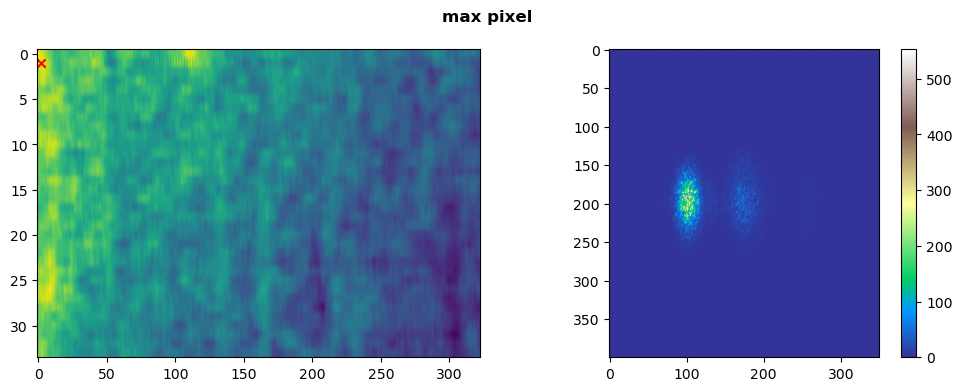

array([[0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(400, 350), dtype=uint32)

In [7]:
id_max, id_min= SDXM.id_RSM(XRD_4dmaps)
plot = id_max
test_data = np.copy(XRD_4dmaps[plot[0], plot[1], :, :])
SDXM.RSMpixel(XRD_4dmaps, (plot[0], plot[1]), lim = np.percentile(XRD_4dmaps[plot[0], plot[1], :, :], 100), title = 'max pixel')

### finnding regions with commom area

In [8]:
XRD_4dmaps14, ext14 = SDXM.RSM_to_map(scan_fixed[14], ROI = ROI)
XRD_4dmaps15, ext15 = SDXM.RSM_to_map(scan_fixed[15], ROI = ROI)
XRD_4dmaps0, ext0 = SDXM.RSM_to_map(scan_fixed[0], ROI = ROI)

(16, 161) (16, 161) (34, 323)


(16, 161, 400, 350)

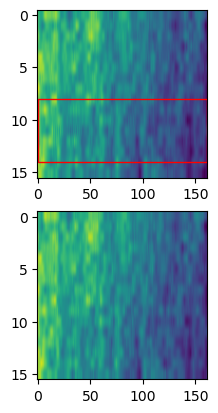

In [9]:
fig, ax = plt.subplots(2,1)
sum14 = np.sum(XRD_4dmaps14, axis = (2,3))
sum15 = np.sum(XRD_4dmaps15, axis = (2,3))
sum0 = np.sum(XRD_4dmaps0, axis = (2,3))
ax[0].imshow(sum14, aspect = 10)
ax[1].imshow(sum15, aspect = 10)
import matplotlib.patches as patches
rect = patches.Rectangle((0, 8), 161, 6, linewidth=1, edgecolor='r', facecolor='none')
ax[0].add_patch(rect)
print(np.shape(sum14), np.shape(sum15), np.shape(sum0))
np.shape(XRD_4dmaps15)

(6, 161)

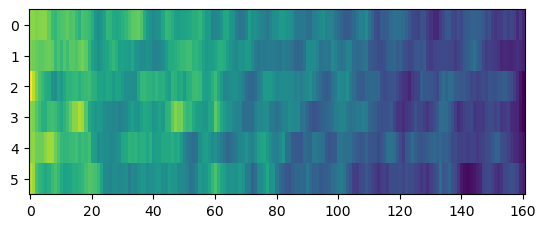

In [10]:
cropp = sum15.copy()
plt.imshow(sum15, aspect = 10)
cropp = cropp[8-3: 8 +3, :]
plt.imshow(cropp, aspect = 10)
np.shape(cropp)

### RSM at 0V

/local/slurmtmp.5179500/ipykernel_495862/4247370487.py:6: RuntimeWarning: divide by zero encountered in log10
  RSM = ax.pcolormesh(Q_ROI[1], Q_ROI[0], np.log10(test_data), cmap = 'magma_r') #x,y, data. this is correct


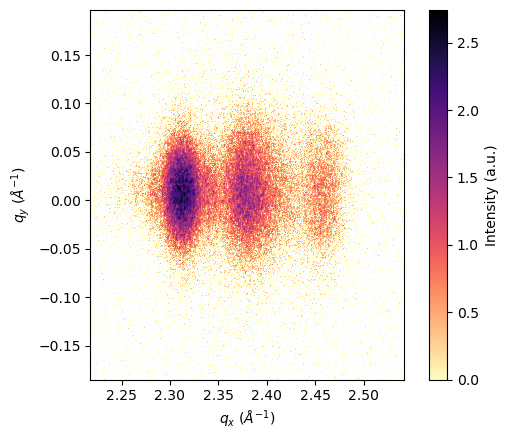

In [11]:
fig, ax  = plt.subplots(dpi = 100)
cleaned = SDXM.clean(XRD_4dmaps, reduce='n', lim=1e4)
test_data = np.copy(cleaned[id_max[0], id_max[1], :, :])
number = 100
test_data[test_data > np.percentile(test_data, number)] = 0 # np.percentile(test_data, number)
RSM = ax.pcolormesh(Q_ROI[1], Q_ROI[0], np.log10(test_data), cmap = 'magma_r') #x,y, data. this is correct
ax.axes.set_aspect('equal', 'box')
ax.set_ylabel(r'$q_y \ (Å^{-1})$')
ax.set_xlabel(r'$q_x \ (Å^{-1})$')
fig.colorbar(RSM, ax = ax, label = 'Intensity (a.u.)')
plt.savefig('RSM_019c.png', bbox_inches='tight', dpi = 600)

In [12]:
# fig, ax = plt.subplots(dpi=100)

# # Clean and clip data
# cleaned = SDXM.clean(XRD_4dmaps, reduce='n', lim=1e3)
# test_data = np.copy(cleaned[id_max[0], id_max[1], :, :])
# number = 100  # for region 1
# # number = 99.5  # for region 2
# clip_val = np.percentile(test_data, number)
# test_data[test_data > clip_val] = clip_val

# # Get extent from Q_ROI: [xmin, xmax, ymin, ymax]
# extent = [
#     Q_ROI[1].min(), Q_ROI[1].max(),  # q_x axis (horizontal)
#     Q_ROI[0].min(), Q_ROI[0].max(),  # q_y axis (vertical)
# ]

# # Display with imshow
# RSM = ax.imshow(
#     test_data,
#     cmap='Blues',  # flip y-axis to match pcolormesh
#     extent=extent,
#     aspect='equal',
#     norm = colors.LogNorm()
# )

# # Labels and colorbar
# ax.set_ylabel(r'$q_y \ (Å^{-1})$')
# ax.set_xlabel(r'$q_x \ (Å^{-1})$')
# fig.colorbar(RSM, ax=ax, label='Intensity (a.u.)')
# #plt.savefig('RSM_019c.svg', bbox_inches='tight', dpi = 600)

## not all scans have detector positions on metadata. 
from hereon i will use the positions from the first dataset

### CGO peak

In [13]:
ROI1 = SDXM.ROI(235, 355, 260, 50)
q_values_1 = SDXM.get_q_2D(scan_fixed_ref)
Q_ROI1 = (q_values_1[:, ROI1['slice'][0], ROI1['slice'][1]])*1e-10 # leftmost peak

# Define the function to process a single scan
def process_scan(scan, volt, ROI = None, Q_ROI = None) :
    #q_values = SDXM.get_q_2D(scan)
    #print(scan)#Q_ROI = (q_values[:, ROI['slice'][0], ROI['slice'][1]])*1e-10
    XRD_4dmaps, _ = SDXM.RSM_to_map(scan, ROI = ROI)
    shape = np.shape(np.sum(XRD_4dmaps, axis = (2,3)))
    if shape[0] == 16:
        XRD_4dmaps = XRD_4dmaps[int(shape[0]/2) - 3:int(shape[0]/2) + 3, :, :, :]
    elif shape[0] == 34:
        XRD_4dmaps = XRD_4dmaps[int(shape[0]/2) - 3:int(shape[0]/2) + 3, int(shape[1]/2 - 161/2): int(shape[1]/2 + 161/2), :, :]
    elif shape[0] == 6:
        XRD_4dmaps = XRD_4dmaps[int(shape[0]/2) - 3:int(shape[0]/2) + 3, int(shape[1]/2 - 161/2): int(shape[1]/2 + 161/2), :, :]
    
    cleaned = SDXM.clean(XRD_4dmaps, reduce = 'n', lim = 1e3)
    #filtered = SDXM.filter(cleaned, kernel = 3)
    ###
    COM_x, COM_y, FWHM_x, FWHM_y, = SDXM.get_moments(cleaned, Q_ROI = Q_ROI)
    Q_mod = np.sqrt(COM_x**2 + COM_y**2)
    ds_map = 2*np.pi/Q_mod
    #strain = 100*(np.mean(ds_map) - ds_map)/np.mean(ds_map)
    tilt = np.rad2deg(np.arcsin(COM_y/Q_mod))
    tilt_0 = np.mean(tilt)
    tilt_alpha = tilt - tilt_0
    FWHM = np.sqrt(FWHM_x**2 + FWHM_y**2)
    FWHM_0 = np.mean(FWHM)
    FWHM_res = FWHM - FWHM_0
    #print(np.shape(cleaned))
    
    return ds_map, tilt, tilt_alpha, FWHM, FWHM_res, XRD_4dmaps

d_spacing = []
tilts = []
tilt_alphas = []
FWHMs = []
FWHMs_rel = []
maps = []
#
for scan, volts in tqdm(zip(scan_fixed, voltage_fixed_kvmm)):
    ds_map, tilt, tilt_alpha, FWHM,  FWHM_rel, XRD_4dmaps = process_scan(scan, volts, ROI = ROI1, Q_ROI= Q_ROI1)
    d_spacing.append(ds_map)
    tilts.append(tilt)
    tilt_alphas.append(tilt_alpha)
    FWHMs.append(FWHM)
    FWHMs_rel.append(FWHM_rel)
    maps.append(np.mean(XRD_4dmaps, axis = (2,3)))

16it [01:09,  4.34s/it]


### HZO-o peak

In [14]:
ROI2 = SDXM.ROI(235, 430, 260, 60) # center peak
q_values2 = SDXM.get_q_2D(scan_fixed_ref)
Q_ROI2 = (q_values2[:, ROI2['slice'][0], ROI2['slice'][1]])*1e-10

d_spacing_2 = []
tilts_2 = []
tilt_alphas_2 = []
FWHMs_2 = []
FWHMs_rel_2 = []
maps_2 = []
#
for scan, volts in tqdm(zip(scan_fixed, voltage_fixed_kvmm)):
    ds_map, tilt, tilt_alpha, FWHM, FWHM_rel, XRD_4dmaps = process_scan(scan, volts, ROI = ROI2, Q_ROI= Q_ROI2)
    d_spacing_2.append(ds_map)
    tilts_2.append(tilt)
    tilt_alphas_2.append(tilt_alpha)
    FWHMs_2.append(FWHM)
    FWHMs_rel_2.append(FWHM_rel)
    maps_2.append(np.mean(XRD_4dmaps, axis = (2,3)))

16it [01:10,  4.38s/it]


### HZO-m peak

In [15]:
ROI3 = SDXM.ROI(235, 520, 260, 60) #y,x, dy, dx
q_values3 = SDXM.get_q_2D(scan_fixed_ref)
Q_ROI3 = (q_values3[:, ROI3['slice'][0], ROI3['slice'][1]])*1e-10 # rightmost peak


d_spacing_3 = []
tilts_3 = []
tilt_alphas_3 = []
FWHMs_3 = []
FWHMs_rel_3 = []
maps_3 = []
#
for scan, volts in tqdm(zip(scan_fixed, voltage_fixed_kvmm)):
    ds_map, tilt, tilt_alpha, FWHM, FWHM_rel, XRD_4dmaps = process_scan(scan, volts, ROI = ROI3, Q_ROI= Q_ROI3)
    d_spacing_3.append(ds_map)
    tilts_3.append(tilt)
    tilt_alphas_3.append(tilt_alpha)
    FWHMs_3.append(FWHM)
    FWHMs_rel_3.append(FWHM_rel)
    maps_3.append(np.mean(XRD_4dmaps, axis = (2,3)))

16it [01:10,  4.41s/it]


### results

6 zeros
6


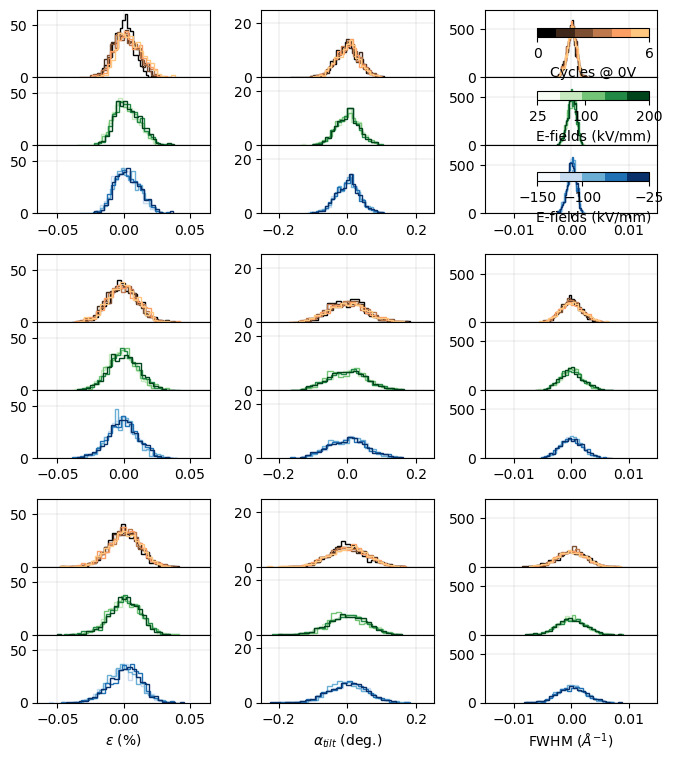

In [16]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import matplotlib as mpl

fig = plt.figure(figsize=(8,9))

# 3 stacked panels (top, middle, bottom)
gs_main = GridSpec(3, 1, figure=fig, height_ratios=[1, 1, 1], hspace=0.2)

# Subgrids for each 3x3 block
gs_top = gs_main[0].subgridspec(3, 3, wspace=0.3, hspace=0)
gs_middle = gs_main[1].subgridspec(3, 3, wspace=0.3, hspace=0)
gs_bottom = gs_main[2].subgridspec(3, 3, wspace=0.3, hspace=0)

# Initialize axes
def create_axes(gridspec):
    axes = [[None for _ in range(3)] for _ in range(3)]
    for row in range(3):
        for col in range(3):
            axes[row][col] = fig.add_subplot(gridspec[row, col])
            if row < 2:
                axes[row][col].set_xticklabels([])
    return axes

ax_top = create_axes(gs_top)
ax_middle = create_axes(gs_middle)
ax_bottom = create_axes(gs_bottom)

# Color maps
print(np.count_nonzero(voltage_fixed == 0), 'zeros')
colors_zero = plt.cm.copper(np.linspace(0, 1, np.count_nonzero(voltage_fixed_kvmm == 0)))
colors_neg = plt.cm.Blues(np.linspace(0, 1, np.count_nonzero(voltage_fixed_kvmm < 0)))
colors_pos = plt.cm.Greens(np.linspace(0, 1, np.count_nonzero(voltage_fixed_kvmm > 0)))

# Plotting function
def plot_data(ax_grid, d_spacing_data, tilts_data, FWHMs_data, d0, bins = None):
    i_zero, i_neg, i_pos = 0, 0, 0
    count = 0
    vzero, vpos, vneg = [], [], []
    
    for ds_map_hist, tilt_hist, FWHM_hist, volts in zip(d_spacing_data, tilts_data, FWHMs_data, voltage_fixed_kvmm):
        strain_map = 100*(ds_map_hist - d0)/d0
        lw = 3
        density = True

        if volts == 0:
            color = colors_zero[i_zero]
            label = f'{int(volts)}V - cycle{count}'
            row = 0
            count += 1
            vzero.append(volts)
            i_zero += 1
        
        elif volts > 0:
            color = colors_pos[i_pos]
            label = f'{int(volts)}V' if volts.is_integer() else f'{volts}V'
            row = 1
            vpos.append(volts)
            i_pos += 1
        
        else:
            color = colors_neg[i_neg]
            label = f'{int(volts)}V' if volts.is_integer() else f'{volts}V'
            row = 2
            vneg.append(volts)
            i_neg += 1
        
        ax_grid[row][0].hist(strain_map.flat, bins=bins, density=density, 
                            histtype='step', color=color, label=label, lw=lw)
        
        ax_grid[row][1].hist(tilt_hist.flat, bins=bins, density=density, 
                            histtype='step', color=color, lw=lw)
        
        ax_grid[row][2].hist(FWHM_hist.flat, bins=bins, density=density, 
                            histtype='step', color=color, lw=lw)
    
    return vzero, vpos, vneg

# Plot data for each ROI
bins = 'fd'
vzero1, vpos1, vneg1 = plot_data(ax_top, d_spacing, tilt_alphas, FWHMs_rel, np.mean(d_spacing[0]), bins = bins)
vzero2, vpos2, vneg2 = plot_data(ax_middle, d_spacing_2, tilt_alphas_2, FWHMs_rel_2, np.mean(d_spacing_2[0]), bins = bins)
vzero3, vpos3, vneg3 = plot_data(ax_bottom, d_spacing_3, tilt_alphas_3, FWHMs_rel_3, np.mean(d_spacing_3[0]), bins = bins)

# Set axis labels and limits
ax_bottom[2][0].set_xlabel(r'$\varepsilon$ (%)')
ax_bottom[2][1].set_xlabel(r'$\alpha_{tilt}$ (deg.)')
ax_bottom[2][2].set_xlabel(r'FWHM ($Å^{-1}$)')

for grid in [ax_top, ax_middle, ax_bottom]:
    for row in range(3):
        grid[row][0].set_xlim(-0.065, 0.065)
        grid[row][0].set_ylim(0, 65)
        grid[row][1].set_xlim(-0.25, 0.25)
        grid[row][1].set_ylim(0, 25)
        grid[row][2].set_xlim(-0.015, 0.015)
        grid[row][2].set_ylim(0, 700)
        for col in range(3):
            grid[row][col].grid(lw=0.2)

# Create colorbars with integer ticks
dx, dy = 0.14, 0.01
xpos = 0.75

# 0V cycles colorbar
cbar_ax = fig.add_axes([xpos, 0.85, dx, dy])
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(0, len(vzero1)), cmap= mpl.colors.ListedColormap(colors_zero)), 
                   cax=cbar_ax, orientation='horizontal', label='Cycles @ 0V')
cbar.set_ticks(np.arange(0, len(vzero1)+1, 6))  # Integer steps
print(len(vzero1))

# Positive voltages colorbar
cbar_ax = fig.add_axes([xpos, 0.78, dx, dy])
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(min(vpos1), max(vpos1)), cmap= mpl.colors.ListedColormap(colors_pos)), 
                   cax=cbar_ax, orientation='horizontal', label='E-fields (kV/mm)')
#cbar.set_ticks([tick for tick in [0.5, 5, 10, 15] if tick <= max(vpos1)])  # Specific ticks
cbar.set_ticks([25, 100, 200])
# Negative voltages colorbar
cbar_ax = fig.add_axes([xpos, 0.69, dx, dy])
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(min(vneg1), max(vneg1)), cmap= mpl.colors.ListedColormap(colors_neg)), 
                   cax=cbar_ax, orientation='horizontal', label='E-fields (kV/mm)')
#cbar.set_ticks([tick for tick in [-0.5, -5, -10, -15] if tick >= min(vneg1)])  # Specific ticks
cbar.set_ticks([-25, -100, -150])
#plt.tight_layout()
#plt.savefig('histograms_019c_new_new_commom.svg', bbox_inches='tight', dpi = 600)
plt.show()

In [17]:
from scipy.optimize import curve_fit
def hist_fit(data, p0 = None):
    hist, bin_edges = np.histogram(data.flat, density = True, bins = 'fd')
    #hist, bin_edges = astrohist(data.flat, density = True, bins = 50)
    bin_centres = (bin_edges[:-1] + bin_edges[1:])/2
    def gauss(x, a, mu, sigma):
        return a*np.exp(-(x-mu)**2/(2*sigma**2))
    #bounds = ([2, -0.1, 1e-9], [70, 0.2, 1])
    #coeff, cov = curve_fit(gauss, bin_centres, hist, p0 = None, bounds = bounds, method = 'trf', maxfev = 20000)
    #
    coeff, cov = curve_fit(gauss, bin_centres, hist, p0 = p0, maxfev = 50000)
    residuals = hist - gauss(bin_centres, *coeff)
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((hist - np.mean(hist))**2)
    r_squared = 1 - (ss_res/ ss_tot)
    #
    return bin_centres, coeff, cov, r_squared

In [28]:
def plot_ROI(ds_map_roi, tilt_roi, FWHM_roi, voltage, mode, p0_s, p0_t, p0_f, col = None):
    i = 0
    v0 = 0
    vp = 0
    vn = 0
    
    zero_strain_std = []
    pos_strain_std = []
    neg_strain_std = []
    
    zero_tilt_std = []
    pos_tilt_std = []
    neg_tilt_std = []
    
    
    zero_FWHM_std = []
    pos_FWHM_std = []
    neg_FWHM_std = []
    
    vpos = []
    vneg = []

    normal_color = "#ffa90d"
    
    for ds_map_hist, tilt_hist, FWHM_hist, volts in zip(ds_map_roi, tilt_roi, FWHM_roi, voltage):
        d0 = np.mean(ds_map_hist[0])
        strain_map = 100*(ds_map_hist - d0)/d0
        
        m = mode
        #print(v0)
        if volts == 0:
            marker = 's'
            if v0 > 0:
                p0_s = coeff_s_zero
                p0_t = coeff_t_zero
                p0_f = coeff_f_zero
                
            
            _, coeff_s_zero, cov_s_zero, _ = hist_fit(strain_map, p0 = p0_s)
            zero_strain_std.append(coeff_s_zero[m])
            
            _, coeff_t_zero, cov_t_zero, _ = hist_fit(tilt_hist, p0 = p0_t)
            zero_tilt_std.append(coeff_t_zero[m])
            
            _, coeff_f_zero, cov_f_zero, _ = hist_fit(FWHM_hist, p0 = p0_f)
            zero_FWHM_std.append(coeff_f_zero[m])
        
            #
            # if col == 0:
            #     colors = plt.cm.winter(np.linspace(0, 1, len(voltage)))
            # elif col == 1:
            #     colors = plt.cm.copper(np.linspace(0, 1, len(voltage)))
            # else:
            #     colors = plt.cm.plasma(np.linspace(0, 1, len(voltage)))
            #
            colors = plt.cm.copper(np.linspace(0, 1, len(voltage)))
            #
            ax[0, col].scatter(volts, coeff_s_zero[m], color = colors[i], label = str(int(volts)) +'V - cicle' + str(v0), marker = marker, facecolors = 'none', s = 50)
            ax[1, col].scatter(volts, coeff_t_zero[m], color = colors[i], label = str(int(volts)) +'V - cicle' + str(v0), marker = marker, facecolors = 'none', s = 50)
            ax[2, col].scatter(volts, coeff_f_zero[m], color = colors[i], label = str(int(volts)) +'V - cicle' + str(v0), marker = marker, facecolors = 'none', s = 50)
            v0 = v0 + 1
        #p0_s = coeff_s
        #p0_t = coeff_t
        #p0_f = coeff_f

        if volts > 0:
            vpos.append(volts)
            
            if vp > 0:
                p0_s = coeff_s_pos
                p0_t = coeff_t_pos
                p0_f = coeff_f_pos
            
            _, coeff_s_pos, cov_s_pos, _ = hist_fit(strain_map, p0 = p0_s)
            pos_strain_std.append(coeff_s_pos[m])
            
            _, coeff_t_pos, cov_t_pos, _ = hist_fit(tilt_hist, p0 = p0_t)
            pos_tilt_std.append(coeff_t_pos[m])
            
            _, coeff_f_pos, cov_f_pos, _ = hist_fit(FWHM_hist, p0 = p0_f)
            pos_FWHM_std.append(coeff_f_pos[m])
            
            marker = '^'
            #print(np.shape(volts), 'volts')
            #print(np.shape(cov_s_pos[m]), 'coeff_s_pos')
            #print(np.sqrt(cov_s_pos[m])[1], 'error')
            ax[0, col].errorbar(volts, coeff_s_pos[m], yerr = np.sqrt(np.diag(cov_s_pos))[m], marker = marker, color = normal_color)#, mfc = 'w')
            ax[1, col].errorbar(volts, coeff_t_pos[m], yerr = np.sqrt(np.diag(cov_t_pos))[m], marker = marker, color = normal_color)#, mfc = 'w')
            ax[2, col].errorbar(volts, coeff_f_pos[m], yerr = np.sqrt(np.diag(cov_f_pos))[m], marker = marker, color = normal_color)#, mfc = 'w')
            #ax[0, col].scatter(volts, coeff_s_pos[m], color = 'b', marker = marker, facecolors = 'none')
            #ax[1, col].scatter(volts, coeff_t_pos[m], color = 'b', marker = marker, facecolors = 'none')
            #ax[2, col].scatter(volts, coeff_f_pos[m], color = 'b', marker = marker, facecolors = 'none')
            vp = vp + 1
    #         ax[1, 0].hist(strain_hist.flat, bins = 100, histtype = 'step', color = colors[i], label = str(volts) + 'V')
    #         ax[1, 1].hist(tilt_hist.flat, bins = 100, histtype = 'step', color = colors[i])
        
        if volts < 0:
            vneg.append(volts)
            #marker = 'v'
            
            if vn > 0:
                p0_s = coeff_s_neg
                p0_t = coeff_t_neg
                p0_f = coeff_f_neg
            _, coeff_s_neg, cov_s_neg, _ = hist_fit(strain_map, p0 = p0_s)
            neg_strain_std.append(coeff_s_neg[m])
            
            _, coeff_t_neg, cov_t_neg, _ = hist_fit(tilt_hist, p0 = p0_t)
            neg_tilt_std.append(coeff_t_neg[m])
            
            _, coeff_f_neg, cov_f_neg, _ = hist_fit(FWHM_hist, p0 = p0_f)
            neg_FWHM_std.append(coeff_f_neg[m])            
            
            #
            ax[0, col].errorbar(volts, coeff_s_neg[m], yerr = np.sqrt(np.diag(cov_s_neg))[m], marker = marker, color = normal_color)#, mfc = 'w')
            ax[1, col].errorbar(volts, coeff_t_neg[m], yerr = np.sqrt(np.diag(cov_t_neg))[m], marker = marker, color = normal_color)#, mfc = 'w')
            ax[2, col].errorbar(volts, coeff_f_neg[m], yerr = np.sqrt(np.diag(cov_f_neg))[m], marker = marker, color = normal_color)#, mfc = 'w')
            #
            #ax[0, col].scatter(volts, coeff_s_neg[m], color = 'g', marker = marker, facecolors = 'none')
            #ax[1, col].scatter(volts, coeff_t_neg[m], color = 'g', marker = marker, facecolors = 'none')
            #ax[2, col].scatter(volts, coeff_f_neg[m], color = 'g', marker = marker, facecolors = 'none')
            vn = vn + 1
        i = i + 1
    #         ax[2, 0].hist(strain_hist.flat, bins = 100, histtype = 'step', color = colors[i], label = str(volts) + 'V')
    #         ax[2, 1].hist(tilt_hist.flat, bins = 100, histtype = 'step', color = colors[i])
    alpha = 1
    ax[0, col].hlines(np.mean(neg_strain_std), xmin = 0, xmax = -15, color = normal_color, linestyles = 'dashed', alpha = alpha)
    ax[0, col].hlines(np.mean(pos_strain_std), xmin = 0, xmax = 15, color = normal_color, linestyles = 'dashed', alpha = alpha)
    #
    ax[1, col].hlines(np.mean(pos_tilt_std), xmin = 0, xmax = 15, color = normal_color, linestyles = 'dashed', alpha = alpha)
    ax[1, col].hlines(np.mean(neg_tilt_std), xmin = 0, xmax = -15, color = normal_color, linestyles = 'dashed', alpha = alpha)
    #
    ax[2, col].hlines(np.mean(pos_FWHM_std), xmin = 0, xmax = 15, color = normal_color, linestyles = 'dashed', alpha = alpha)
    ax[2, col].hlines(np.mean(neg_FWHM_std), xmin = 0, xmax = -15, color = normal_color, linestyles = 'dashed', alpha = alpha)
    #
    ax[0, col].scatter(0, np.mean(zero_strain_std), marker = '*', s = 80, color = "#bc1e00", edgecolor = 'k', zorder = 100)
    ax[1, col].scatter(0, np.mean(zero_tilt_std), marker = '*', s = 80, color = "#bc1e00", edgecolor = 'k', zorder = 100)
    ax[2, col].scatter(0, np.mean(zero_FWHM_std), marker = '*', s = 80, color = "#bc1e00", edgecolor = 'k', zorder = 100)
    #
    # #splines
    # #
    # spl = CubicSpline(vpos, pos_strain_std)
    # xnew = np.linspace(np.min(vpos), np.max(vpos), num=50)
    # ax[0, col].plot(xnew, spl(xnew), color = 'b')
    # #
    # spl = CubicSpline(vpos, pos_tilt_std)
    # xnew = np.linspace(np.min(vpos), np.max(vpos), num=50)
    # ax[1, col].plot(xnew, spl(xnew), color = 'b')
    # #
    # spl = CubicSpline(vpos, pos_FWHM_std)
    # xnew = np.linspace(np.min(vpos), np.max(vpos), num=50)
    # ax[2, col].plot(xnew, spl(xnew), color = 'b')
    # ######################
    # spl = CubicSpline(vpos, neg_strain_std)
    # xnew = np.linspace(np.min(vpos), np.max(vpos), num=50)
    # ax[0, col].plot(-xnew, spl(xnew), color = 'g')
    # #
    # spl = CubicSpline(vpos, neg_tilt_std)
    # xnew = np.linspace(np.min(vpos), np.max(vpos), num=50)
    # ax[1, col].plot(-xnew, spl(xnew), color = 'g')
    # #
    # spl = CubicSpline(vpos, neg_FWHM_std)
    # xnew = np.linspace(np.min(vpos), np.max(vpos), num=50)
    # ax[2, col].plot(-xnew, spl(xnew), color = 'g')
    # #
    
    if m == 1:
        ax[0, 0].set_ylabel(r'${\varepsilon}$ (%)')
        ax[1, 0].set_ylabel(r'${\alpha}_{tilt}$ (deg.)')
        ax[2, 0].set_ylabel(r'${\text{FWHM}}$ ($Å^{-1}$)')
    else:
        ax[0, 0].set_ylabel(r'STD $\varepsilon$')
        ax[1, 0].set_ylabel(r'STD $\alpha_{\text{tilt}}$')
        ax[2, 0].set_ylabel(r'STD $\text{FWHM} (Å^{-1}$)')

    # for i in range(3):
    #     ax[i, 1].set_xticks(np.arange(-15, 16, 5))


    ################ piecewise fitting
    # pos_strain_std.insert(0, np.mean(zero_strain_std))
    # pos_tilt_std.insert(0, np.mean(zero_tilt_std))
    # pos_FWHM_std.insert(0, np.mean(zero_FWHM_std))
    # #
    # neg_strain_std.insert(0, np.mean(zero_strain_std))
    # neg_tilt_std.insert(0, np.mean(zero_tilt_std))
    # neg_FWHM_std.insert(0, np.mean(zero_FWHM_std))
    # #
    v_up = [i for i in voltage if i > 0] #ascending
    # v_up.insert(0, 0)
    v_down = [i for i in voltage if i < 0]
    # v_down.insert(0, 0)

    def piecewise(x, y):
        model = pwlf.PiecewiseLinFit(x, y)
        
        # Fit with 1 segment
        model.fit(1)
        y_hat_1 = model.predict(x)
        r2_1 = model.r_squared()

        # Fit with 2 segments
        model.fit(2)
        y_hat_2 = model.predict(x)
        r2_2 = model.r_squared()

        # Choose the better one
        if r2_2 > r2_1:
            best_model = pwlf.PiecewiseLinFit(x, y)
            best_model.fit(1)
        else:
            best_model = pwlf.PiecewiseLinFit(x, y)
            best_model.fit(1)
        
        xHat = np.linspace(min(x), max(x), num=100)
        yHat = best_model.predict(xHat)
        return xHat, yHat


    x_up_strain, PW_up_strain = piecewise(v_up, pos_strain_std)
    x_up_tilt, PW_up_tilt = piecewise(v_up, pos_tilt_std)
    x_up_FWHM, PW_up_FWHM = piecewise(v_up, pos_FWHM_std)
    #
    x_down_strain, PW_down_strain = piecewise(v_down, neg_strain_std)
    x_down_tilt, PW_down_tilt = piecewise(v_down, neg_tilt_std)
    x_down_FWHM, PW_down_FWHM = piecewise(v_down, neg_FWHM_std)
    
    fit_color = 'red'
    ax[0, col].plot(x_up_strain, PW_up_strain, color = fit_color, zorder = 100)
    ax[1, col].plot(x_up_tilt, PW_up_tilt, color = fit_color, zorder = 100)
    ax[2, col].plot(x_up_FWHM, PW_up_FWHM, color = fit_color, zorder = 100)

    ax[0, col].plot(x_down_strain, PW_down_strain, color = fit_color, zorder = 100)
    ax[1, col].plot(x_down_tilt, PW_down_tilt, color = fit_color, zorder = 100)
    ax[2, col].plot(x_down_FWHM, PW_down_FWHM, color = fit_color, zorder = 100)

#plt.savefig('means_022a.svg', bbox_inches='tight', dpi = 600)

In [29]:
def plot_ROI_twin(ds_map_roi, tilt_roi, FWHM_roi, voltage, mode, p0_s, p0_t, p0_f, col = None):
    i = 0
    v0 = 0
    vp = 0
    vn = 0
    zero_strain_std = []
    pos_strain_std = []
    neg_strain_std = []
    
    zero_tilt_std = []
    pos_tilt_std = []
    neg_tilt_std = []
    
    
    zero_FWHM_std = []
    pos_FWHM_std = []
    neg_FWHM_std = []
    
    vpos = []
    vneg = []
    #
    ax0c = ax[0, col].twinx()
    ax0c.set_ylim(0.0077, 0.0197)
    
    #for k in [1, 2]:
    #    ax[0, k].twinx().sharey(ax0c)
    #
    ax1c = ax[1, col].twinx()
    ax1c.set_ylim(0.028, 0.069)
    #for kk in [1,2]:
    #    ax[1, kk].twinx().sharey(ax1c)
        
    twin_color = "#3f90da"

    ax2c = ax[2, col].twinx()
    ax2c.set_ylim(0.0006, 0.0035)
    if col == ax.shape[1] - 1:  # Only label the last column's twin axis in last row
        ax0c.set_ylabel(r"$\sigma_{\varepsilon}$ (%)", color= twin_color)
        ax1c.set_ylabel(r"$\sigma_{\alpha_{tilt}}$ (.deg)  ", color= twin_color)
        ax2c.set_ylabel(r"$\sigma_{\text{FWHM}} (Å^{-1})$  ", color= twin_color)
    else:
        ax0c.set_yticklabels([])
        ax1c.set_yticklabels([])
        ax2c.set_yticklabels([])

    

    #for kkk in [1,2]:
    #    ax[2, kkk].twinx().sharey(ax2c)

    #ax2c.set_ylabel("Your Label Here", color="b")
    
    # for axs in [ax0c, ax1c, ax2c]:
    #     axs.set_ylim(0.0077, 0.0197)

    for axs in [ax0c, ax1c, ax2c]:    
        axs.spines["right"].set_color(twin_color)
        axs.tick_params(axis='y', colors=twin_color)
        axs.yaxis.label.set_color(twin_color)
    
    for ds_map_hist, tilt_hist, FWHM_hist, volts in zip(ds_map_roi, tilt_roi, FWHM_roi, voltage):
        #colors = plt.cm.copper(np.linspace(0, 1, len(voltage)))
        d0 = np.mean(ds_map_hist[0])
        strain_map = 100*(ds_map_hist - d0)/d0
        
        m = mode
        #print(v0)
        if volts == 0:
            marker = 's'
            if v0 > 0:
                p0_s = coeff_s_zero
                p0_t = coeff_t_zero
                p0_f = coeff_f_zero
                
            
            _, coeff_s_zero, cov_s_zero, _ = hist_fit(strain_map, p0 = p0_s)
            zero_strain_std.append(coeff_s_zero[m])
            
            _, coeff_t_zero, cov_t_zero, _ = hist_fit(tilt_hist, p0 = p0_t)
            zero_tilt_std.append(coeff_t_zero[m])
            
            _, coeff_f_zero, cov_f_zero, _ = hist_fit(FWHM_hist, p0 = p0_f)
            zero_FWHM_std.append(coeff_f_zero[m])
        
            #
            #
            # if col == 0:
            #     colors = plt.cm.winter(np.linspace(0, 1, len(voltage)))
            # elif col == 1:
            #     colors = plt.cm.copper(np.linspace(0, 1, len(voltage)))
            # else:
            colors = plt.cm.copper(np.linspace(0, 1, len(voltage)))
            #
            ax0c.scatter(volts, coeff_s_zero[m], color = colors[i], label = str(int(volts)) +'V - cicle' + str(v0), marker = marker, s = 50)
            ax1c.scatter(volts, coeff_t_zero[m], color = colors[i], label = str(int(volts)) +'V - cicle' + str(v0), marker = marker, s = 50)
            ax2c.scatter(volts, coeff_f_zero[m], color = colors[i], label = str(int(volts)) +'V - cicle' + str(v0), marker = marker, s = 50)
            v0 = v0 + 1
        #p0_s = coeff_s
        #p0_t = coeff_t
        #p0_f = coeff_f

        if volts > 0:
            vpos.append(volts)
            
            if vp > 0:
                p0_s = coeff_s_pos
                p0_t = coeff_t_pos
                p0_f = coeff_f_pos
            
            _, coeff_s_pos, cov_s_pos, _ = hist_fit(strain_map, p0 = p0_s)
            pos_strain_std.append(coeff_s_pos[m])
            
            _, coeff_t_pos, cov_t_pos, _ = hist_fit(tilt_hist, p0 = p0_t)
            pos_tilt_std.append(coeff_t_pos[m])
            
            _, coeff_f_pos, cov_f_pos, _ = hist_fit(FWHM_hist, p0 = p0_f)
            pos_FWHM_std.append(coeff_f_pos[m])
            
            marker = '^'
            #print(np.shape(volts), 'volts')
            #print(np.shape(cov_s_pos[m]), 'coeff_s_pos')
            #print(np.sqrt(cov_s_pos[m])[1], 'error')
            ax0c.errorbar(volts, coeff_s_pos[m], yerr = np.sqrt(np.diag(cov_s_pos))[m], marker = marker, color = twin_color)#, mfc = 'w')
            ax1c.errorbar(volts, coeff_t_pos[m], yerr = np.sqrt(np.diag(cov_t_pos))[m], marker = marker, color = twin_color)#, mfc = 'w')
            ax2c.errorbar(volts, coeff_f_pos[m], yerr = np.sqrt(np.diag(cov_f_pos))[m], marker = marker, color = twin_color)#, mfc = 'w')
            #ax[0, col].scatter(volts, coeff_s_pos[m], color = 'b', marker = marker, facecolors = 'none')
            #ax[1, col].scatter(volts, coeff_t_pos[m], color = 'b', marker = marker, facecolors = 'none')
            #ax[2, col].scatter(volts, coeff_f_pos[m], color = 'b', marker = marker, facecolors = 'none')
            vp = vp + 1
    #         ax[1, 0].hist(strain_hist.flat, bins = 100, histtype = 'step', color = colors[i], label = str(volts) + 'V')
    #         ax[1, 1].hist(tilt_hist.flat, bins = 100, histtype = 'step', color = colors[i])
        
        if volts < 0:
            vneg.append(volts)
            marker = 'v'
            
            if vn > 0:
                p0_s = coeff_s_neg
                p0_t = coeff_t_neg
                p0_f = coeff_f_neg
            _, coeff_s_neg, cov_s_neg, _ = hist_fit(strain_map, p0 = p0_s)
            neg_strain_std.append(coeff_s_neg[m])
            
            _, coeff_t_neg, cov_t_neg, _ = hist_fit(tilt_hist, p0 = p0_t)
            neg_tilt_std.append(coeff_t_neg[m])
            
            _, coeff_f_neg, cov_f_neg, _ = hist_fit(FWHM_hist, p0 = p0_f)
            neg_FWHM_std.append(coeff_f_neg[m])            
            
            #
            ax0c.errorbar(volts, coeff_s_neg[m], yerr = np.sqrt(np.diag(cov_s_neg))[m], marker = marker, color = twin_color)#, mfc = 'w')
            ax1c.errorbar(volts, coeff_t_neg[m], yerr = np.sqrt(np.diag(cov_t_neg))[m], marker = marker, color = twin_color)#, mfc = 'w')
            ax2c.errorbar(volts, coeff_f_neg[m], yerr = np.sqrt(np.diag(cov_f_neg))[m], marker = marker, color = twin_color)#, mfc = 'w')
            #
            #ax[0, col].scatter(volts, coeff_s_neg[m], color = 'g', marker = marker, facecolors = 'none')
            #ax[1, col].scatter(volts, coeff_t_neg[m], color = 'g', marker = marker, facecolors = 'none')
            #ax[2, col].scatter(volts, coeff_f_neg[m], color = 'g', marker = marker, facecolors = 'none')
            vn = vn + 1
        i = i + 1
    #         ax[2, 0].hist(strain_hist.flat, bins = 100, histtype = 'step', color = colors[i], label = str(volts) + 'V')
    #         ax[2, 1].hist(tilt_hist.flat, bins = 100, histtype = 'step', color = colors[i])
    alpha = 1
    ax0c.hlines(np.mean(neg_strain_std), xmin = 0, xmax = -15, color = twin_color, linestyles = 'dashed', alpha = alpha)
    ax0c.hlines(np.mean(pos_strain_std), xmin = 0, xmax = 15, color = twin_color, linestyles = 'dashed', alpha = alpha)
    #
    ax1c.hlines(np.mean(pos_tilt_std), xmin = 0, xmax = 15, color = twin_color, linestyles = 'dashed', alpha = alpha)
    ax1c.hlines(np.mean(neg_tilt_std), xmin = 0, xmax = -15, color = twin_color, linestyles = 'dashed', alpha = alpha)
    #
    ax2c.hlines(np.mean(pos_FWHM_std), xmin = 0, xmax = 15, color = twin_color, linestyles = 'dashed', alpha = alpha)
    ax2c.hlines(np.mean(neg_FWHM_std), xmin = 0, xmax = -15, color = twin_color, linestyles = 'dashed', alpha = alpha)
    #
    ax0c.scatter(0, np.mean(zero_strain_std), marker = '*', s = 80, color = "#bc1e00", edgecolor = 'k', zorder = 100)
    ax1c.scatter(0, np.mean(zero_tilt_std), marker = '*', s = 80, color = "#bc1e00", edgecolor = 'k', zorder = 100)
    ax2c.scatter(0, np.mean(zero_FWHM_std), marker = '*', s = 80, color = "#bc1e00", edgecolor = 'k', zorder = 100)

    ################ piecewise fitting
    #pos_strain_std.insert(0, np.mean(zero_strain_std))
    #pos_tilt_std.insert(0, np.mean(zero_tilt_std))
    #pos_FWHM_std.insert(0, np.mean(zero_FWHM_std))
    #
    #neg_strain_std.insert(0, np.mean(zero_strain_std))
    #neg_tilt_std.insert(0, np.mean(zero_tilt_std))
    #neg_FWHM_std.insert(0, np.mean(zero_FWHM_std))
    #
    v_up = [i for i in voltage if i > 0] #ascending
    #v_up.insert(0, 0)
    v_down = [i for i in voltage if i < 0]
    #v_down.insert(0, 0)

    def piecewise(x, y):
        model = pwlf.PiecewiseLinFit(x, y)
        
        # Fit with 1 segment
        model.fit(1)
        y_hat_1 = model.predict(x)
        r2_1 = model.r_squared()

        # Fit with 2 segments
        model.fit(2)
        y_hat_2 = model.predict(x)
        r2_2 = model.r_squared()
        print(r2_1, r2_2 , r2_1 - r2_2)

        # Choose the better one
        if  r2_2 < r2_1:
            best_model = pwlf.PiecewiseLinFit(x, y)
            best_model.fit(1)
        else:
            best_model = pwlf.PiecewiseLinFit(x, y)
            best_model.fit(1)
        
        xHat = np.linspace(min(x), max(x), num=100)
        yHat = best_model.predict(xHat)
        return xHat, yHat

    x_up_strain, PW_up_strain = piecewise(v_up, pos_strain_std)
    x_up_tilt, PW_up_tilt = piecewise(v_up, pos_tilt_std)
    x_up_FWHM, PW_up_FWHM = piecewise(v_up, pos_FWHM_std)
    #
    x_down_strain, PW_down_strain = piecewise(v_down, neg_strain_std)
    x_down_tilt, PW_down_tilt = piecewise(v_down, neg_tilt_std)
    x_down_FWHM, PW_down_FWHM = piecewise(v_down, neg_FWHM_std)
    fit_color = 'b'
    ax0c.plot(x_up_strain, PW_up_strain, color = fit_color, zorder = 100)
    ax1c.plot(x_up_tilt, PW_up_tilt, color = fit_color, zorder = 100)
    ax2c.plot(x_up_FWHM, PW_up_FWHM, color = fit_color, zorder = 100)

    ax0c.plot(x_down_strain, PW_down_strain, color = fit_color, zorder = 100)
    ax1c.plot(x_down_tilt, PW_down_tilt, color = fit_color, zorder = 100)
    ax2c.plot(x_down_FWHM, PW_down_FWHM, color = fit_color, zorder = 100)

# not mean values

0.00500567261153273 0.5795781191185363 -0.5745724465070036
0.06030605843802661 0.8724348844839409 -0.8121288260459143
0.0016060772059467432 0.3274486680651637 -0.32584259085921696
0.1423323557377112 0.5733832886466659 -0.4310509329089547
0.4935994768873475 0.7026294055424137 -0.2090299286550662
0.08593278397984827 0.1857185407472951 -0.09978575676744683
0.5395648449619821 0.8664995046444683 -0.32693465968248625
0.17448066393368944 0.9932694868302792 -0.8187888228965897
0.3870800922768012 0.7346561988276916 -0.34757610655089044
0.0012298007802620248 0.62313714930745 -0.621907348527188
0.03327916069197778 0.26274774301512416 -0.22946858232314638
0.44441094137298853 0.5539243754506662 -0.10951343407767766
0.8626686741500649 0.9544271225273154 -0.09175844837725056
0.03698561668472289 0.8731017326723125 -0.8361161159875896
0.647575193903164 0.8942688889903619 -0.24669369508719796
0.17923753818674681 0.9481608593938478 -0.7689233212071009
0.1023112477253858 0.28119264718999226 -0.17888139946

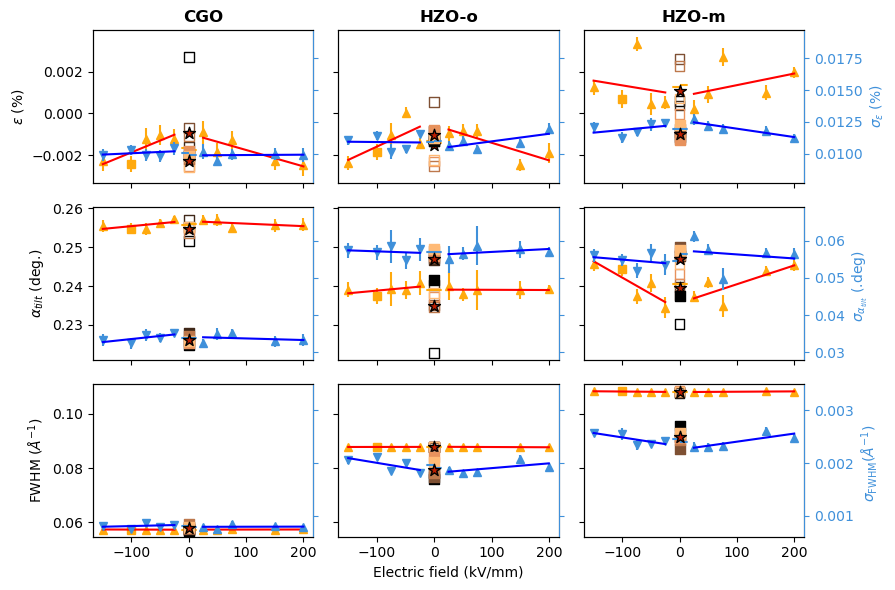

In [30]:
fig, ax = plt.subplots(3,3, figsize = (9, 6),  sharex =  'col', sharey =  'row')
#######################################################################################
p0_s = [50, 0, 0.005] #amplitude-center-std
p0_t = [15, 0.25, np.std(tilts[0]*0.9)]
p0_f = [500, np.mean(FWHMs[0]), np.std(FWHMs[0])*0.9]   
plot_ROI(d_spacing, tilts, FWHMs, voltage_fixed_kvmm, 1, p0_s, p0_t, p0_f, col = 0)
plot_ROI_twin(d_spacing, tilts, FWHMs, voltage_fixed_kvmm, 2, p0_s, p0_t, p0_f, col = 0)
#######################################################################################
p0_s = [40, 0, 0.005] #amplitude-center-std
p0_t = [10, 0.25, np.std(tilts_2[0]*0.9)]
p0_f = [200, np.mean(FWHMs_2[0]), np.std(FWHMs_2[0])*0.9]
plot_ROI(d_spacing_2, tilts_2, FWHMs_2, voltage_fixed_kvmm, 1, p0_s, p0_t, p0_f, col = 1)
plot_ROI_twin(d_spacing_2, tilts_2, FWHMs_2, voltage_fixed_kvmm, 2, p0_s, p0_t, p0_f, col = 1)
#######################################################################################
p0_s = [50, 0, 0.005] #amplitude-center-std
p0_t = [10, 0.25, np.std(tilts_3[0]*0.9)]
p0_f = [150, np.mean(FWHMs_3[0]), np.std(FWHMs_3[0])*0.9]
plot_ROI(d_spacing_3, tilts_3, FWHMs_3, voltage_fixed_kvmm, 1, p0_s, p0_t, p0_f, col = 2)
plot_ROI_twin(d_spacing_3, tilts_3, FWHMs_3, voltage_fixed_kvmm, 2, p0_s, p0_t, p0_f, col = 2)
#######################################################################################
ax[0,0].set_title('CGO', fontweight = 'bold')
ax[0,1].set_title('HZO-o', fontweight = 'bold')
ax[0,2].set_title('HZO-m', fontweight = 'bold')
ax[2, 1].set_xlabel('Electric field (kV/mm)')

plt.tight_layout()
#plt.savefig('histograms_019c_histfit_new_commom.svg', bbox_inches='tight', dpi = 600)


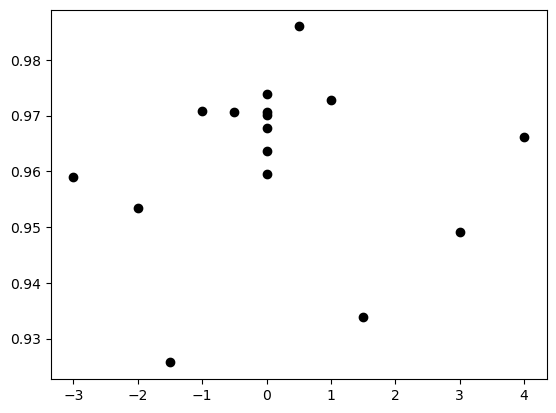

In [21]:
p0_s = [50, 0, 0.005] #amplitude-center-std
p0_t = [15, 0.25, np.std(tilts[0]*0.9)]
p0_f = [500, np.mean(FWHMs[0]), np.std(FWHMs[0])*0.9]   

#for in zip(d_spacing, tilts, FWHMs, p0_s, p0_t, p0_f):
for snum, (i, j) in enumerate(zip(FWHMs, voltage_fixed)):
    _, coeff, cov, r = hist_fit(i, p0 = p0_f)
    plt.scatter(j, r, color = 'k')